# UrbanFlow Barcelona - EDA y transformación del GTFS

Este notebook realiza el análisis exploratorio (EDA) y las transformaciones

aplicadas al GTFS de TMB.

El proceso se divide en tres fases:

1. Análisis inicial de los datos Raw.

2. Aplicación de las transformaciones de limpieza y normalización.

3. Análisis final de los datos transformados.

El objetivo es comprobar la estructura, calidad, integridad y evolución de

los datos antes de almacenarlos en la capa Processed.

## Importación de librerías

Importamos las librerías necesarias para cargar, analizar, transformar y visualizar los datos GTFS.

In [5]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_DIR = Path.cwd().parent

os.environ["URBANFLOW_BASE_DIR"] = str(PROJECT_DIR)

sys.path.append(str(PROJECT_DIR))


from utils.config import (
    BASE_DIR,
    TMB_RAW_DIR,
    TMB_PROCESSED_DIR,
)

## Localización del GTFS

Buscamos automáticamente la extracción GTFS más reciente disponible en la capa Raw para trabajar siempre con la última versión descargada.

In [6]:
BASE_DIR = Path("..")

TMB_RAW_DIR = BASE_DIR / "data" / "raw" / "tmb"

gtfs_dirs = [
    directory
    for directory in TMB_RAW_DIR.iterdir()
    if directory.is_dir()
    and (directory / "extracted").exists()
]

if not gtfs_dirs:
    raise FileNotFoundError(
        "No se ha encontrado ningún GTFS descargado."
    )

latest_dir = max(
    gtfs_dirs,
    key=lambda directory: directory.name,
)

GTFS_DIR = latest_dir / "extracted"

print(f"GTFS utilizado: {GTFS_DIR}")

GTFS utilizado: ../data/raw/tmb/2026-09-14/extracted


## Carga de los datasets

Cargamos los principales archivos GTFS como DataFrames de pandas.

Todos los campos se cargan inicialmente como texto para evitar conversiones
automáticas de tipos antes del proceso de transformación.

In [7]:
agency = pd.read_csv(
    GTFS_DIR / "agency.txt",
    dtype=str,
)

routes = pd.read_csv(
    GTFS_DIR / "routes.txt",
    dtype=str,
)

trips = pd.read_csv(
    GTFS_DIR / "trips.txt",
    dtype=str,
)

stops = pd.read_csv(
    GTFS_DIR / "stops.txt",
    dtype=str,
)

stop_times = pd.read_csv(
    GTFS_DIR / "stop_times.txt",
    dtype=str,
)

calendar = pd.read_csv(
    GTFS_DIR / "calendar.txt",
    dtype=str,
)

dataframes = {
    "agency": agency,
    "routes": routes,
    "trips": trips,
    "stops": stops,
    "stop_times": stop_times,
    "calendar": calendar,
}

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## Análisis inicial: volumen de los datasets

Comenzamos comprobando el número de registros y columnas de cada dataset.
Esto permite conocer el volumen inicial del GTFS antes de aplicar cualquier
transformación.

In [8]:
initial_summary = pd.DataFrame(
    {
        "dataset": list(dataframes.keys()),
        "filas": [
            dataframe.shape[0]
            for dataframe in dataframes.values()
        ],
        "columnas": [
            dataframe.shape[1]
            for dataframe in dataframes.values()
        ],
    }
)

initial_summary

,dataset,filas,columnas
0,agency,1,5
1,routes,116,7
2,trips,60537,7
3,stops,3445,9
4,stop_times,1391617,5
5,calendar,4,10


### Distribución del volumen de datos

Representamos gráficamente el número de registros de cada dataset.

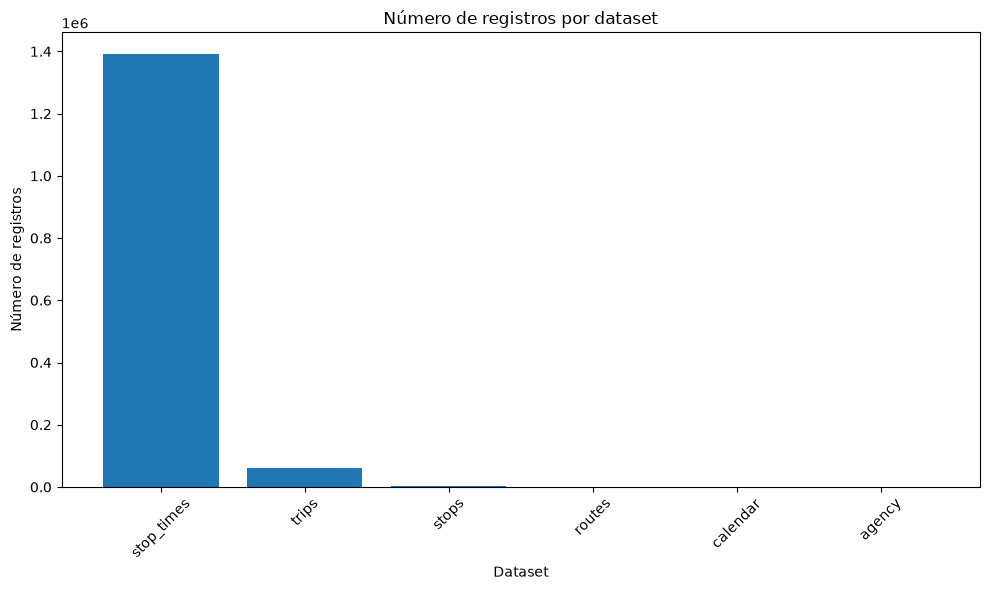

In [9]:
summary_plot = initial_summary.sort_values(
    "filas",
    ascending=False,
)

plt.figure(figsize=(10, 6))

plt.bar(
    summary_plot["dataset"],
    summary_plot["filas"],
)

plt.title("Número de registros por dataset")
plt.xlabel("Dataset")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Análisis inicial de estructura y calidad

Para cada dataset analizamos:

- Los primeros cinco registros.
- Sus dimensiones.
- Los tipos de datos.
- Sus estadísticas descriptivas.
- Los valores nulos.
- Los registros completamente duplicados.

Este análisis establece el estado inicial de los datos antes de realizar
cualquier transformación.

In [10]:
for name, dataframe in dataframes.items():
    print(f"DATASET: {name}")

    print("\nPrimeros 5 registros:")
    print(dataframe.head(5).to_string(index=False))

    print("\nDimensiones:")
    print(dataframe.shape)

    print("\nTipos de datos:")
    print(dataframe.dtypes)

    print("\nEstadísticas descriptivas:")
    print(dataframe.describe(include="all"))

    print("\nValores nulos:")
    print(dataframe.isna().sum())

    print("\nRegistros duplicados:")
    print(dataframe.duplicated().sum())

DATASET: agency

Primeros 5 registros:
agency_name          agency_url agency_timezone agency_lang agency_phone
        TMB https://www.tmb.cat   Europe/Madrid          ca 900 70 11 49

Dimensiones:
(1, 5)

Tipos de datos:
agency_name        str
agency_url         str
agency_timezone    str
agency_lang        str
agency_phone       str
dtype: object

Estadísticas descriptivas:
       agency_name           agency_url agency_timezone agency_lang  \
count            1                    1               1           1   
unique           1                    1               1           1   
top            TMB  https://www.tmb.cat   Europe/Madrid          ca   
freq             1                    1               1           1   

        agency_phone  
count              1  
unique             1  
top     900 70 11 49  
freq               1  

Valores nulos:
agency_name        0
agency_url         0
agency_timezone    0
agency_lang        0
agency_phone       0
dtype: int64

Registros dupl

## Integridad referencial

Comprobamos que las relaciones principales entre los datasets GTFS sean correctas.

Se verificará que:

- Todos los `route_id` utilizados en `trips` existan en `routes`.

- Todos los `trip_id` utilizados en `stop_times` existan en `trips`.

- Todos los `stop_id` utilizados en `stop_times` existan en `stops`.

De esta forma comprobamos que no existan registros que hagan referencia a

entidades inexistentes.

In [11]:
print("INTEGRIDAD REFERENCIAL")

# trips.route_id -> routes.route_id

invalid_route_ids = (
    ~trips["route_id"].isin(routes["route_id"])
).sum()
print(
    f"trips.route_id sin correspondencia en routes: "
    f"{invalid_route_ids}"
)

# stop_times.trip_id -> trips.trip_id

invalid_trip_ids = (
    ~stop_times["trip_id"].isin(trips["trip_id"])
).sum()

print(
    f"stop_times.trip_id sin correspondencia en trips: "
    f"{invalid_trip_ids}"
)

# stop_times.stop_id -> stops.stop_id

invalid_stop_ids = (
    ~stop_times["stop_id"].isin(stops["stop_id"])
).sum()

print(
    f"stop_times.stop_id sin correspondencia en stops: "
    f"{invalid_stop_ids}"
)

#usamos el  ~ para invertir el booleano

INTEGRIDAD REFERENCIAL
trips.route_id sin correspondencia en routes: 0
stop_times.trip_id sin correspondencia en trips: 0
stop_times.stop_id sin correspondencia en stops: 0


## Calidad de las coordenadas de las paradas

Analizamos las coordenadas geográficas de las paradas para comprobar que existan valores válidos en `stop_lat` y `stop_lon`.
Estas coordenadas serán necesarias posteriormente para realizar análisis geográficos y representar la distribución de las paradas de TMB.

In [12]:
print("CALIDAD DE LAS COORDENADAS")

missing_lat = stops["stop_lat"].isna().sum()
missing_lon = stops["stop_lon"].isna().sum()

print(f"Paradas sin latitud: {missing_lat}")
print(f"Paradas sin longitud: {missing_lon}")

print("\nRango de latitud:")
print(
    f"Mínimo: {pd.to_numeric(stops['stop_lat']).min():.6f}"
)
print(
    f"Máximo: {pd.to_numeric(stops['stop_lat']).max():.6f}"
)

print("\nRango de longitud:")
print(
    f"Mínimo: {pd.to_numeric(stops['stop_lon']).min():.6f}"
)
print(
    f"Máximo: {pd.to_numeric(stops['stop_lon']).max():.6f}"
)

CALIDAD DE LAS COORDENADAS
Paradas sin latitud: 0
Paradas sin longitud: 0

Rango de latitud:
Mínimo: 41.287565
Máximo: 41.499727

Rango de longitud:
Mínimo: 2.046171
Máximo: 2.245194


## Mapa interactivo de la red de Metro

Representamos las paradas pertenecientes a la red de Metro de Barcelona

utilizando el color identificativo de cada línea.

Cuando una parada pertenece a una única línea, se muestra utilizando el

color correspondiente a dicha línea.

Cuando varias líneas de Metro pasan por una misma parada, el punto se

representa en color gris neutro.

Al pasar el ratón sobre una parada se muestra su nombre, `stop_id` y todas

las líneas que pasan por ella.

In [13]:
import plotly.express as px
import pandas as pd


# Relacionamos paradas con viajes y líneas

metro_stop_routes = (
    stop_times[
        [
            "stop_id",
            "trip_id",
        ]
    ]
    .merge(
        trips[
            [
                "trip_id",
                "route_id",
            ]
        ],
        on="trip_id",
        how="inner",
    )
    .merge(
        routes[
            [
                "route_id",
                "route_short_name",
                "route_type",
            ]
        ],
        on="route_id",
        how="inner",
    )
)


# Filtramos únicamente las líneas de Metro

metro_stop_routes = metro_stop_routes[
    metro_stop_routes["route_type"] == "1"
]


# Eliminamos relaciones duplicadas entre parada y línea

metro_stop_routes = metro_stop_routes.drop_duplicates(
    subset=[
        "stop_id",
        "route_id",
    ]
)


# Añadimos información de las paradas

metro_stop_routes = metro_stop_routes.merge(
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
        ]
    ],
    on="stop_id",
    how="inner",
)


# Convertimos las coordenadas

metro_stop_routes["stop_lat"] = pd.to_numeric(
    metro_stop_routes["stop_lat"],
    errors="coerce",
)

metro_stop_routes["stop_lon"] = pd.to_numeric(
    metro_stop_routes["stop_lon"],
    errors="coerce",
)


# Eliminamos coordenadas no válidas

metro_stop_routes = metro_stop_routes.dropna(
    subset=[
        "stop_lat",
        "stop_lon",
    ]
)


# Colores oficiales del Metro

metro_colors = {
    "L1": "#E23A3C",
    "L2": "#9E469C",
    "L3": "#52BA54",
    "L4": "#FEBE14",
    "L5": "#327ACC",
    "L6": "#867EC4",
    "L7": "#AE621C",
    "L8": "#E27AB4",
    "L9N": "#F6862C",
    "L9S": "#F6862C",
    "L10N": "#02AEEC",
    "L10S": "#02AEEC",
    "L11": "#AAD264",
    "L12": "#B6B3E1",
}


# Asignamos el color de cada línea

metro_stop_routes["color"] = (
    metro_stop_routes["route_short_name"]
    .map(metro_colors)
    .fillna("#808080")
)


# Agrupamos todas las líneas de cada parada

metro_stops = (
    metro_stop_routes
    .groupby(
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
        ],
        as_index=False,
    )
    .agg(
        route_count=(
            "route_short_name",
            "nunique",
        ),
        routes=(
            "route_short_name",
            lambda values: ", ".join(
                sorted(
                    set(values),
                    key=str,
                )
            ),
        ),
        colors=(
            "color",
            lambda values: list(values),
        ),
    )
)


# Una línea -> color de la línea
# Varias líneas -> gris

metro_stops["display_color"] = metro_stops.apply(
    lambda row:
        row["colors"][0]
        if row["route_count"] == 1
        else "#666666",
    axis=1,
)


# Información de control

print(
    f"Paradas de Metro representadas: "
    f"{len(metro_stops):,}"
)

print(
    f"Paradas con una línea: "
    f"{(metro_stops['route_count'] == 1).sum():,}"
)

print(
    f"Paradas con varias líneas: "
    f"{(metro_stops['route_count'] > 1).sum():,}"
)


# Creamos el mapa interactivo

fig_metro = px.scatter_map(
    metro_stops,
    lat="stop_lat",
    lon="stop_lon",
    hover_name="stop_name",
    hover_data={
        "stop_id": True,
        "routes": True,
        "route_count": False,
        "stop_lat": False,
        "stop_lon": False,
        "colors": False,
        "display_color": False,
    },
    color="display_color",
    color_discrete_map="identity",
    zoom=11,
    center={
        "lat": 41.3874,
        "lon": 2.1686,
    },
    height=750,
)


fig_metro.update_traces(
    marker={
        "size": 9,
        "opacity": 0.85,
    }
)


fig_metro.update_layout(
    title="Mapa interactivo de las paradas de Metro de Barcelona",
    map_style="open-street-map",
    margin={
        "l": 0,
        "r": 0,
        "t": 50,
        "b": 0,
    },
)


fig_metro.show()

Paradas de Metro representadas: 163
Paradas con una línea: 157
Paradas con varias líneas: 6


## Mapa interactivo de la red de Autobuses

Representamos las paradas pertenecientes a la red de autobuses de TMB
utilizando la codificación cromática de la Nova Xarxa de Bus.

Se utilizan los siguientes colores:

- Líneas convencionales: rojo.
- Líneas verticales `V`: verde.
- Líneas horizontales `H`: azul.
- Líneas diagonales `D`: morado.

Cuando una parada pertenece a una única línea se muestra con el color de
dicha línea.

Cuando varias líneas pasan por una misma parada, se utiliza un color gris
neutro.

Al pasar el ratón sobre una parada se muestra su nombre, `stop_id` y todas
las líneas que pasan por ella.

In [14]:
# Relacionamos paradas con viajes y líneas

bus_stop_routes = (
    stop_times[
        [
            "stop_id",
            "trip_id",
        ]
    ]
    .merge(
        trips[
            [
                "trip_id",
                "route_id",
            ]
        ],
        on="trip_id",
        how="inner",
    )
    .merge(
        routes[
            [
                "route_id",
                "route_short_name",
                "route_type",
            ]
        ],
        on="route_id",
        how="inner",
    )
)


# Filtramos únicamente las líneas de autobús

bus_stop_routes = bus_stop_routes[
    bus_stop_routes["route_type"] == "3"
]


# Eliminamos relaciones duplicadas entre parada y línea

bus_stop_routes = bus_stop_routes.drop_duplicates(
    subset=[
        "stop_id",
        "route_id",
    ]
)


# Añadimos información de las paradas

bus_stop_routes = bus_stop_routes.merge(
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
        ]
    ],
    on="stop_id",
    how="inner",
)


# Convertimos las coordenadas

bus_stop_routes["stop_lat"] = pd.to_numeric(
    bus_stop_routes["stop_lat"],
    errors="coerce",
)

bus_stop_routes["stop_lon"] = pd.to_numeric(
    bus_stop_routes["stop_lon"],
    errors="coerce",
)


# Eliminamos coordenadas no válidas

bus_stop_routes = bus_stop_routes.dropna(
    subset=[
        "stop_lat",
        "stop_lon",
    ]
)


# Colores de la red de autobuses

BUS_RED = "#E23A3C"
BUS_GREEN = "#009966"
BUS_BLUE = "#0072BB"
BUS_PURPLE = "#952B89"


def get_bus_color(route_name):
    """
    Asigna el color correspondiente a cada línea de autobús.
    """

    route_name = str(route_name).strip()

    # Líneas verticales

    if route_name.startswith("V"):
        return BUS_GREEN

    # Líneas horizontales

    if route_name.startswith("H"):
        return BUS_BLUE

    # Líneas diagonales

    if route_name.startswith("D"):
        return BUS_PURPLE

    # Líneas convencionales

    return BUS_RED


# Asignamos el color de cada línea

bus_stop_routes["color"] = (
    bus_stop_routes["route_short_name"]
    .apply(get_bus_color)
)


# Agrupamos todas las líneas de cada parada

bus_stops = (
    bus_stop_routes
    .groupby(
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
        ],
        as_index=False,
    )
    .agg(
        route_count=(
            "route_short_name",
            "nunique",
        ),
        routes=(
            "route_short_name",
            lambda values: ", ".join(
                sorted(
                    set(values),
                    key=str,
                )
            ),
        ),
        colors=(
            "color",
            lambda values: list(values),
        ),
    )
)


# Una línea -> color de la línea
# Varias líneas -> gris

bus_stops["display_color"] = bus_stops.apply(
    lambda row:
        row["colors"][0]
        if row["route_count"] == 1
        else "#666666",
    axis=1,
)


# Información de control

print(
    f"Paradas de Bus representadas: "
    f"{len(bus_stops):,}"
)

print(
    f"Paradas con una línea: "
    f"{(bus_stops['route_count'] == 1).sum():,}"
)

print(
    f"Paradas con varias líneas: "
    f"{(bus_stops['route_count'] > 1).sum():,}"
)


# Creamos el mapa interactivo

fig_bus = px.scatter_map(
    bus_stops,
    lat="stop_lat",
    lon="stop_lon",
    hover_name="stop_name",
    hover_data={
        "stop_id": True,
        "routes": True,
        "route_count": False,
        "stop_lat": False,
        "stop_lon": False,
        "colors": False,
        "display_color": False,
    },
    color="display_color",
    color_discrete_map="identity",
    zoom=11,
    center={
        "lat": 41.3874,
        "lon": 2.1686,
    },
    height=750,
)


fig_bus.update_traces(
    marker={
        "size": 7,
        "opacity": 0.65,
    }
)


fig_bus.update_layout(
    title="Mapa interactivo de las paradas de Autobús de Barcelona",
    map_style="open-street-map",
    margin={
        "l": 0,
        "r": 0,
        "t": 50,
        "b": 0,
    },
)


fig_bus.show()

Paradas de Bus representadas: 2,605
Paradas con una línea: 1,492
Paradas con varias líneas: 1,113


# Exploratory Data Analysis

## Distribución de las rutas por tipo de transporte

Analizamos la distribución de las rutas según `route_type`.

El objetivo es conocer qué tipos de transporte tienen mayor presencia
dentro del GTFS de TMB.

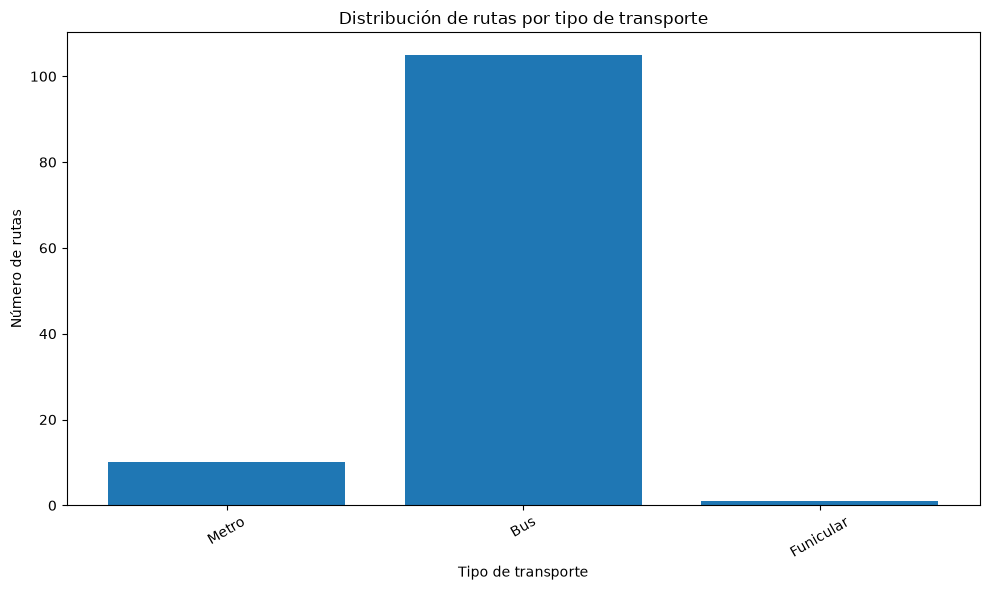

In [15]:
route_type_counts = (
    routes["route_type"]
    .value_counts()
    .sort_index()
)

route_type_labels = {
    "0": "Tranvía",
    "1": "Metro",
    "2": "Ferrocarril",
    "3": "Bus",
    "4": "Ferry",
    "5": "Teleférico",
    "6": "Telecabina",
    "7": "Funicular",
}

route_type_counts.index = [
    route_type_labels.get(
        route_type,
        f"Tipo {route_type}"
    )
    for route_type in route_type_counts.index
]

plt.figure(figsize=(10, 6))

plt.bar(
    route_type_counts.index,
    route_type_counts.values,
)

plt.title("Distribución de rutas por tipo de transporte")
plt.xlabel("Tipo de transporte")
plt.ylabel("Número de rutas")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Rutas con más de viajes programados

Analizamos qué rutas tienen un mayor número de viajes programados en el
dataset `trips`.

Este análisis permite identificar las líneas con mayor oferta de servicios
dentro del GTFS analizado.

,route_short_name,route_long_name,num_trips
7,L5,Cornellà Centre - Vall d'Hebron,4160
0,L1,Hospital de Bellvitge - Fondo,2370
5,L3,Zona Universitària - Trinitat Nova,2284
6,L4,La Pau - Trinitat Nova,2173
4,L2,Paral·lel - Badalona Pompeu Fabra,2078
2,L10N,La Sagrera - Gorg,1865
9,L9N,La Sagrera - Can Zam,1856
8,L9S,Aeroport T1 - Zona Universitària,1796
1,L10S,ZAL | Riu Vell - Collblanc,1782
3,L11,Trinitat Nova - Can Cuiàs,1413


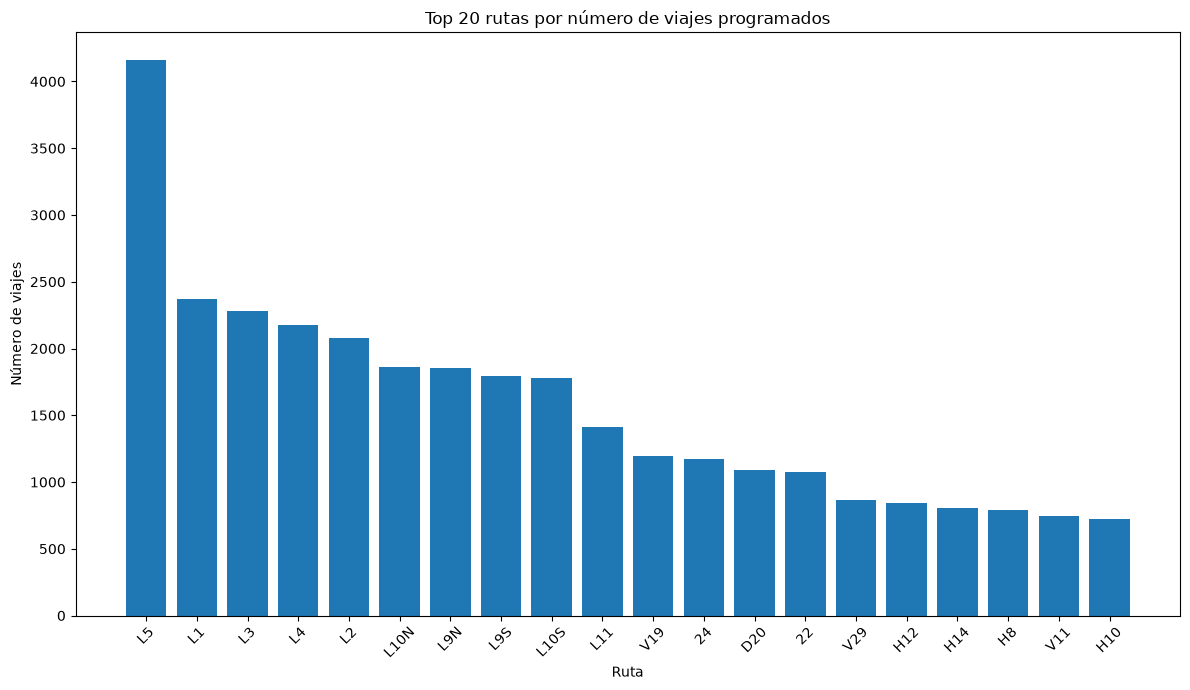

In [16]:
trips_per_route = (
    trips
    .groupby("route_id")
    .size()
    .reset_index(name="num_trips")
)

trips_per_route = (
    trips_per_route
    .merge(
        routes[
            [
                "route_id",
                "route_short_name",
                "route_long_name",
            ]
        ],
        on="route_id",
        how="left",
    )
    .sort_values(
        "num_trips",
        ascending=False,
    )
)

top_routes = trips_per_route.head(20)

display(
    top_routes[
        [
            "route_short_name",
            "route_long_name",
            "num_trips",
        ]
    ]
)

plt.figure(figsize=(12, 7))

plt.bar(
    top_routes["route_short_name"].fillna(
        top_routes["route_id"]
    ),
    top_routes["num_trips"],
)

plt.title("Top 20 rutas por número de viajes programados")
plt.xlabel("Ruta")
plt.ylabel("Número de viajes")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Distribución del número de viajes por ruta

Analizamos la distribución del número de viajes programados por ruta para
observar cómo se reparte la oferta de transporte entre las diferentes líneas.

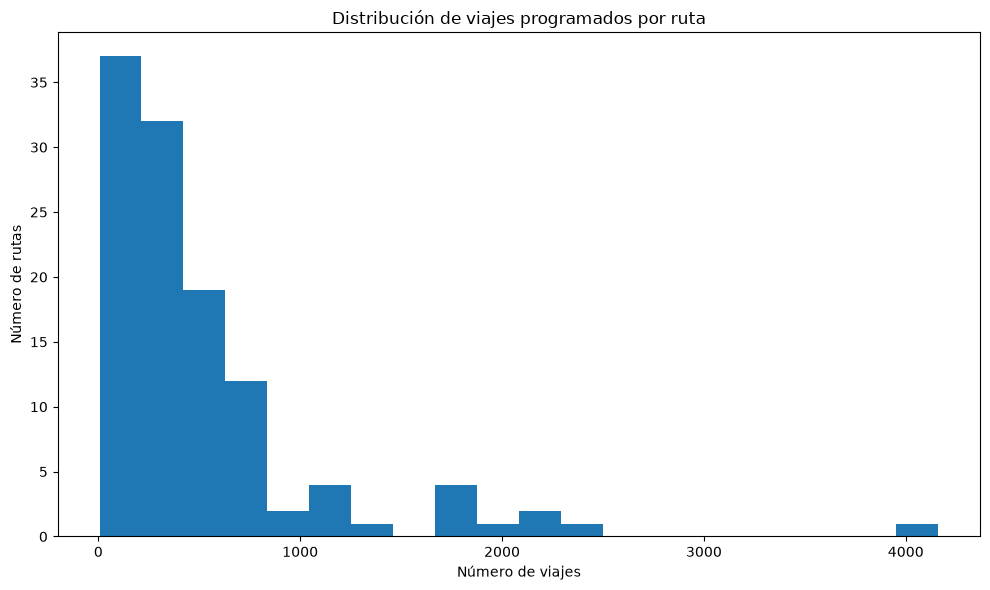

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    trips_per_route["num_trips"],
    bins=20,
)

plt.title("Distribución de viajes programados por ruta")
plt.xlabel("Número de viajes")
plt.ylabel("Número de rutas")

plt.tight_layout()
plt.show()

# Transformaciones

## Copia de los datos Raw

Antes de aplicar las transformaciones se realiza una copia de los DataFrames originales. De esta forma se mantiene separado el dataset Raw y las modificaciones se aplican únicamente sobre los datos transformados.

In [18]:
transformed = {
    name: dataframe.copy()
    for name, dataframe in dataframes.items()
}

print("Copia de los datos Raw creada correctamente.")

Copia de los datos Raw creada correctamente.


## Limpieza de nombres de columnas

Eliminamos espacios innecesarios al principio y al final de los nombres de
las columnas para mantener un esquema consistente.

In [19]:
for dataframe in transformed.values():

    dataframe.columns = (
        dataframe.columns
        .str.strip()
    )

print("Nombres de columnas normalizados correctamente.")

Nombres de columnas normalizados correctamente.


## Normalización de valores de texto

Eliminamos espacios innecesarios de los valores de texto y convertimos las
cadenas vacías en valores nulos (`NA`).

Esto permite mantener una representación consistente de los valores vacíos.

In [20]:
for dataframe in transformed.values():

    object_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in object_columns:

        dataframe[column] = (
            dataframe[column]
            .str.strip()
            .replace("", pd.NA)
        )

print("Valores de texto normalizados correctamente.")

Valores de texto normalizados correctamente.


## Conversión de coordenadas

Convertimos `stop_lat` y `stop_lon` del dataset `stops` a valores numéricos.

Esto permite realizar posteriormente operaciones y análisis geográficos

sobre las coordenadas.

In [21]:
stops_transformed = transformed["stops"]

stops_transformed["stop_lat"] = pd.to_numeric(
    stops_transformed["stop_lat"],
    errors="coerce",
)

stops_transformed["stop_lon"] = pd.to_numeric(
    stops_transformed["stop_lon"],
    errors="coerce",
)

print("Coordenadas convertidas a valores numéricos.")

Coordenadas convertidas a valores numéricos.


## Conversión de stop_sequence

Convertimos `stop_sequence` del dataset `stop_times` a un tipo numérico.

Este campo representa el orden en el que se recorren las paradas dentro de

cada viaje.

In [22]:
stop_times_transformed = transformed["stop_times"]

stop_times_transformed["stop_sequence"] = pd.to_numeric(
    stop_times_transformed["stop_sequence"],
    errors="coerce",
)

print("stop_sequence convertido a valores numéricos.")

stop_sequence convertido a valores numéricos.


## Eliminación de registros duplicados

Eliminamos registros completamente duplicados de cada dataset.

Esta operación evita conservar varias copias idénticas de un mismo registro.

In [23]:
for name, dataframe in transformed.items():

    before = len(dataframe)

    transformed[name] = dataframe.drop_duplicates()

    after = len(transformed[name])

    print(
        f"{name}: {before - after} duplicados eliminados"
    )

agency: 0 duplicados eliminados
routes: 0 duplicados eliminados
trips: 0 duplicados eliminados
stops: 0 duplicados eliminados
stop_times: 0 duplicados eliminados
calendar: 0 duplicados eliminados


## Eliminación de stop_id duplicados

Comprobamos que cada `stop_id` identifique una única parada. En caso de encontrar varios registros con el mismo identificador, se conserva únicamente el primero.

In [24]:
stops_transformed = transformed["stops"]

before = len(stops_transformed)

stops_transformed = stops_transformed.drop_duplicates(
    subset=["stop_id"],
    keep="first",
)

transformed["stops"] = stops_transformed

print(
    f"stops: {before - len(stops_transformed)} "
    "stop_id duplicados eliminados"
)

stops: 0 stop_id duplicados eliminados


## Eliminación de registros sin identificadores

Eliminamos los registros que no contienen los identificadores principales
necesarios para relacionar los diferentes datasets.

Se aplican las siguientes reglas:

- `route_id` en `routes`
- `trip_id` en `trips`
- `stop_id` en `stops`
- `trip_id` y `stop_id` en `stop_times`
- `service_id` en `calendar`

In [25]:
for name, dataframe in transformed.items():

    identifier_columns = []

    if name == "routes":
        identifier_columns = ["route_id"]

    elif name == "trips":
        identifier_columns = ["trip_id"]

    elif name == "stops":
        identifier_columns = ["stop_id"]

    elif name == "stop_times":
        identifier_columns = [
            "trip_id",
            "stop_id",
        ]

    elif name == "calendar":
        identifier_columns = ["service_id"]

    if identifier_columns:

        before = len(dataframe)

        dataframe = dataframe.dropna(
            subset=identifier_columns,
        )

        transformed[name] = dataframe

        print(
            f"{name}: "
            f"{before - len(dataframe)} "
            "registros sin identificadores eliminados"
        )

routes: 0 registros sin identificadores eliminados
trips: 0 registros sin identificadores eliminados
stops: 0 registros sin identificadores eliminados
stop_times: 0 registros sin identificadores eliminados
calendar: 0 registros sin identificadores eliminados


## Eliminación de paradas sin coordenadas

Eliminamos las paradas que no disponen de latitud o longitud.

Las coordenadas son necesarias para los análisis geográficos posteriores,
por lo que una parada sin posición válida no puede utilizarse correctamente
en este tipo de análisis.

In [26]:
stops_transformed = transformed["stops"]

before = len(stops_transformed)

stops_transformed = stops_transformed.dropna(
    subset=[
        "stop_lat",
        "stop_lon",
    ],
)

transformed["stops"] = stops_transformed

print(
    f"stops: {before - len(stops_transformed)} "
    "registros sin coordenadas eliminados"
)

stops: 0 registros sin coordenadas eliminados


## Guardado de los datos transformados

Finalmente, los DataFrames transformados se guardan en la zona `Processed`

del proyecto.

Los datos se almacenan separados por fecha para mantener la trazabilidad de

cada ejecución del pipeline.

In [27]:

date = GTFS_DIR.parent.name

output_dir = TMB_PROCESSED_DIR / date

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for name, dataframe in transformed.items():

    output_file = output_dir / f"{name}.csv"

    dataframe.to_csv(
        output_file,
        index=False,
    )

    print(
        f"{name}: {len(dataframe)} registros guardados"
    )

print(f"\nDatos Processed guardados en: {output_dir}")

agency: 1 registros guardados
routes: 116 registros guardados
trips: 60537 registros guardados
stops: 3445 registros guardados
stop_times: 1391617 registros guardados
calendar: 4 registros guardados

Datos Processed guardados en: /Users/yagoalonso/Documents/UrbanFlow/data/processed/tmb/2026-09-14


# Análisis final

## Comparación de registros antes y después de la transformación

Comparamos el número de registros de cada dataset antes y después de las transformaciones. Esto permite comprobar el impacto real de las reglas de limpieza aplicadas.

In [28]:
comparison = pd.DataFrame(
    {
        "dataset": list(dataframes.keys()),
        "registros_raw": [
            len(dataframe)
            for dataframe in dataframes.values()
        ],
        "registros_processed": [
            len(transformed[name])
            for name in dataframes.keys()
        ],
    }
)

comparison["registros_eliminados"] = (
    comparison["registros_raw"]
    - comparison["registros_processed"]
)

display(comparison)

,dataset,registros_raw,registros_processed,registros_eliminados
0,agency,1,1,0
1,routes,116,116,0
2,trips,60537,60537,0
3,stops,3445,3445,0
4,stop_times,1391617,1391617,0
5,calendar,4,4,0


## Comprobaciones de calidad finales

Volvemos a comprobar algunas reglas de calidad sobre los datos transformados.

Se comprueba que no existan registros completamente duplicados y que los
identificadores principales de las paradas sigan siendo únicos.

In [29]:
print("CALIDAD FINAL DE LOS DATOS")

for name, dataframe in transformed.items():

    print(f"\n{name}")

    print(
        f"Registros: {len(dataframe)}"
    )

    print(
        f"Duplicados: {dataframe.duplicated().sum()}"
    )

stops_final = transformed["stops"]

print(
    "\nstop_id duplicados:",
    stops_final["stop_id"].duplicated().sum(),
)

CALIDAD FINAL DE LOS DATOS

agency
Registros: 1
Duplicados: 0

routes
Registros: 116
Duplicados: 0

trips
Registros: 60537
Duplicados: 0

stops
Registros: 3445
Duplicados: 0

stop_times
Registros: 1391617
Duplicados: 0

calendar
Registros: 4
Duplicados: 0

stop_id duplicados: 0


## Integridad referencial final

Comprobamos nuevamente las relaciones principales después de las

transformaciones para asegurar que el proceso de limpieza no haya generado

referencias inválidas.

In [30]:
routes_final = transformed["routes"]
trips_final = transformed["trips"]
stops_final = transformed["stops"]
stop_times_final = transformed["stop_times"]

invalid_route_ids = (
    ~trips_final["route_id"].isin(
        routes_final["route_id"]
    )
).sum()

invalid_trip_ids = (
    ~stop_times_final["trip_id"].isin(
        trips_final["trip_id"]
    )
).sum()

invalid_stop_ids = (
    ~stop_times_final["stop_id"].isin(
        stops_final["stop_id"]
    )
).sum()

print(
    f"trips.route_id inválidos: {invalid_route_ids}"
)

print(
    f"stop_times.trip_id inválidos: {invalid_trip_ids}"
)

print(
    f"stop_times.stop_id inválidos: {invalid_stop_ids}"
)

trips.route_id inválidos: 0
stop_times.trip_id inválidos: 0
stop_times.stop_id inválidos: 0


# Conclusiones

El GTFS de TMB analizado presenta una estructura consistente y una calidad de datos adecuada para continuar con el pipeline de Data Engineering.

El dataset contiene 116 rutas, 60.537 viajes, 3.445 paradas y 1.391.617 registros en stop_times. La integridad referencial es correcta, ya que todos los route_id, trip_id y stop_id utilizados tienen una entidad correspondiente.

La red está formada principalmente por autobuses, con 105 rutas de tipo bus, 10 rutas de metro y 1 ruta de tipo funicular. Las rutas con mayor número de viajes programados son principalmente líneas de metro como L5, L1, L3, L4 y L2.

Todas las paradas disponen de coordenadas válidas dentro del área analizada, lo que permite realizar análisis geográficos y representar la distribución de la red de transporte.

Los valores nulos detectados se concentran principalmente en campos que pueden ser opcionales o que presentan información parcial. En stops, stop_url no contiene valores informados y parent_station y wheelchair_boarding presentan algunos valores nulos. En stop_times, 764.691 registros no contienen arrival_time ni departure_time. Estos valores no se imputan durante esta fase, ya que cualquier tratamiento de los horarios debería realizarse de acuerdo con la lógica del estándar GTFS y las necesidades del análisis posterior.

Las transformaciones aplicadas normalizan los nombres de columnas y los valores de texto, convierten las coordenadas y stop_sequence a tipos numéricos y eliminan posibles registros duplicados, registros sin identificadores necesarios y paradas sin coordenadas.

En el GTFS analizado ninguna de estas reglas ha provocado una reducción del número de registros, ya que no se han encontrado duplicados, identificadores nulos ni paradas sin coordenadas.

Los datos transformados quedan preparados para las siguientes fases del proyecto, donde podrán utilizarse para procesos de Data Engineering, almacenamiento en la zona Processed y posteriores análisis mediante Spark, PostgreSQL y herramientas de visualización.